# Example 5: XGBoost

## XGBoost
`XGBoost (Extreme Gradient Boosting)` is a high-performance implementation of gradient boosted decision trees, designed for speed and efficiency. It builds an ensemble of trees sequentially, where each new tree corrects the errors made by the previous ones. XGBoost includes advanced features like regularization, tree pruning, and parallel processing, which help improve accuracy and prevent overfitting. It supports both classification and regression tasks and is widely used in machine learning competitions and real-world applications. Its popularity comes from its scalability, ease of use, and strong performance on structured/tabular data.

### References
- https://xgboost.readthedocs.io/en/stable/


## KDDCup99 dataset
The `KDDCup99 dataset` is a benchmark dataset created for the 1999 KDD Cup competition, which focused on developing models for network intrusion detection. It consists of connection logs from a simulated military network environment, where each record represents a network session and is labeled as either normal or one of several attack types (e.g., DoS, probe, R2L, U2R). Each connection is described by 41 features, including both continuous and categorical variables like duration, protocol type, and number of failed login attempts. The dataset is known for its large size and class imbalance, with some attack types being very rare. Despite its age, KDDCup99 remains a popular benchmark for evaluating anomaly detection and classification algorithms in cybersecurity.

In [20]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_kddcup99
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

In [21]:
np.random.seed(1337)

In [22]:
# Load the KDDCup99 dataset (subset for speed)
print("Loading KDDCup99 dataset...")
dataset = fetch_kddcup99(subset='SA', percent10=True, shuffle=True, as_frame=True)
print('Done!')

Loading KDDCup99 dataset...
Done!


In [23]:
# Separate features and target
x = dataset.data
y = dataset.target

In [24]:
# Preview the dataset

In [25]:
x.head()  # show first 5 rows of features

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,b'tcp',b'http',b'SF',293,2714,0,0,0,0,...,255,255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,b'tcp',b'http',b'SF',308,2618,0,0,0,0,...,69,255,1.0,0.0,0.01,0.03,0.0,0.0,0.0,0.0
2,0,b'tcp',b'http',b'SF',301,1075,0,0,0,0,...,255,251,0.98,0.01,0.0,0.0,0.0,0.0,0.0,0.0
3,0,b'tcp',b'http',b'SF',239,2507,0,0,0,0,...,255,225,0.88,0.02,0.0,0.0,0.0,0.0,0.0,0.0
4,2,b'udp',b'private',b'SF',105,146,0,0,0,0,...,255,244,0.96,0.01,0.01,0.0,0.0,0.0,0.0,0.0


In [26]:
x.tail()  # show last 5 rows of features

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
100650,0,b'tcp',b'http',b'SF',197,304,0,0,0,0,...,255,255,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100651,0,b'tcp',b'http',b'SF',378,2656,0,0,0,0,...,74,255,1.0,0.0,0.01,0.01,0.0,0.01,0.0,0.0
100652,0,b'tcp',b'http',b'SF',267,204,0,0,0,0,...,25,255,1.0,0.0,0.04,0.08,0.0,0.0,0.0,0.0
100653,0,b'udp',b'private',b'SF',105,0,0,0,0,0,...,255,233,0.91,0.01,0.0,0.0,0.0,0.0,0.0,0.0
100654,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [27]:
y.head()  # show first 5 labels

0    b'normal.'
1    b'normal.'
2    b'normal.'
3    b'normal.'
4    b'normal.'
Name: labels, dtype: object

In [28]:
y.tail()  # show last 5 labels

100650    b'normal.'
100651    b'normal.'
100652    b'normal.'
100653    b'normal.'
100654     b'smurf.'
Name: labels, dtype: object

In [29]:
# Encode categorical features using Label Encoding

In [30]:
x = x.copy()
for col in x.select_dtypes(include='object').columns:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])

In [31]:
# Convert to binary classification: 1 = attack, 0 = normal
y = (y != b'normal.').astype(np.int64)

In [32]:
# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [33]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [34]:
# Train Gradient Boosting model using scikit-learn
start = time.time()
skl_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
skl_model.fit(x_train, y_train)
skl_time = time.time() - start  # measure training time

In [35]:
# Evaluate scikit-learn skl_model model
skl_pred = skl_model.predict(x_test)
skl_acc = accuracy_score(y_test, skl_pred)
skl_auc = roc_auc_score(y_test, skl_model.predict_proba(x_test)[:, 1])  # use predicted probability for AUC

In [36]:
# Train XGBoost model
start = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, y_train)
xgb_time = time.time() - start  # measure training time

In [37]:
# Evaluate XGBoost model
xgb_pred = xgb_model.predict(x_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(x_test)[:, 1])  # use predicted probability for AUC

In [38]:
# Print comparison results
print(f"Scikit-learn skl_model - Accuracy: {skl_acc:.4f}, AUC: {skl_auc:.4f}, Training Time: {skl_time:.2f}s")
print(f"xGBoost           - Accuracy: {xgb_acc:.4f}, AUC: {xgb_auc:.4f}, Training Time: {xgb_time:.2f}s")

Scikit-learn skl_model - Accuracy: 0.9998, AUC: 0.9998, Training Time: 7.34s
xGBoost           - Accuracy: 0.9997, AUC: 1.0000, Training Time: 0.13s


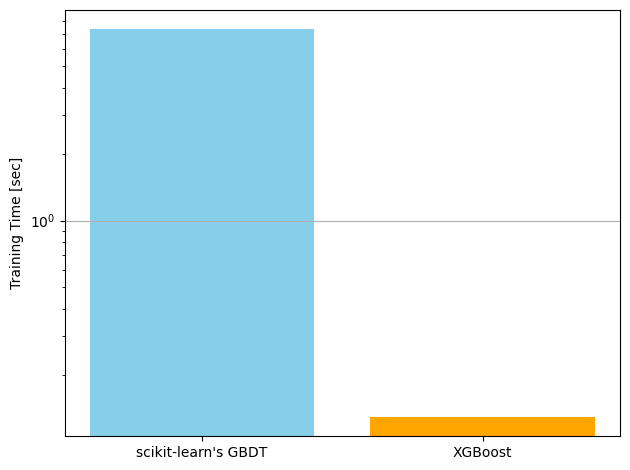

In [48]:
fig, ax = plt.subplots()
ax.bar(
    ["scikit-learn's GBDT", 'XGBoost'], 
    [skl_time, xgb_time],
    color=['skyblue', 'orange'],
)
ax.set_ylabel('Training Time [sec]')
ax.grid(axis='y')
ax.set_yticks([0.01, 0.1, 1, 10])
ax.set_yscale('log')
fig.tight_layout()